In [1]:
# Prepare Data
import os
import sys
import yaml
import torch
import pickle
import warnings
import setproctitle
import numpy as np
import sympy as sp
import pandas as pd
import torch.utils.data as D
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display
from copy import deepcopy
from scipy.optimize import minimize
from nd2.model import NDformer
from nd2.utils import init_logger
from nd2.search import MCTS
from nd2.GDExpr import GDExpr
from nd2.dataset import Dataset
from nd2.utils import AttrDict, get_fig, seed_all
from nd2.search.reward_solver import RewardSolver, RolloutRewardSolver

warnings.filterwarnings("ignore", category=RuntimeWarning)
seed_all(42)


df = pd.read_csv('./data/gene/data.csv', index_col=0)
data = df.values

T = data.shape[0] - 1 # 17 - 1 = 16
V = data.shape[1] # 7
E = V * (V - 1) # 42
A = 1 - np.eye(V) # (V, V)
G = np.stack(np.nonzero(A), axis=-1) # (E, 2)

x = np.array(data[:-1, :]) # (T, V)
dx = np.diff(data, axis=0) # (T, V)
data = dict(V=V, E=E, A=A, G=G, dx=dx, x=x)

In [ ]:
if False:
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import pairwise_distances
    import numpy as np

    df = pd.read_csv('./data/gene/2010.Spellman98_cdc15.flt.knn.avg.pcl', sep='\t')
    df.drop(columns=['YORF', 'NAME', 'GWEIGHT'], inplace=True)
    df.columns = [i[-7:-4] for i in df.columns]
    df.drop(columns='min', inplace=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    df['cluster'] = labels
    df = df.groupby('cluster').mean().T
    df.columns = [f'Type{i+1}' for i in df.columns]
    df.columns.name = None
    df.index.name = 'time'
    df.index = df.index.astype(int)
    df.to_csv('./data/gene/data2.csv')

    data = df.values
    T = data.shape[0] - 1 # 17 - 1 = 16
    V = data.shape[1] # 7
    E = V * (V - 1) # 42
    A = 1 - np.eye(V) # (V, V)
    G = np.stack(np.nonzero(A), axis=-1) # (E, 2)

    x = np.array(data[:-1, :]) # (T, V)
    dx = np.diff(data, axis=0) # (T, V)
    data = dict(V=V, E=E, A=A, G=G, dx=dx, x=x)

In [2]:
reward_solver = RewardSolver(
    Xv={'x': data['x']},
    Xe={},
    A=data['A'],
    G=data['G'],
    Y=data['dx']
)

def evaluate(expr, N=10, x0=None, max_iter=100):
    prefix = GDExpr.sympy2prefix(GDExpr.parse_expr(expr), 'node', reindex=False, keep_coeff=True)
    prefix_with_coef = reward_solver.solve(prefix, x0=x0, max_iter=max_iter)[1]
    single_step = reward_solver.evaluate(prefix_with_coef)

    true = np.concatenate([data['x'], data['x'][(-1,), :] + data['dx'][(-1,), :]], axis=0)
    pred = [data['x'][[0]]]
    for t in range(T):
        for n in range(N):
            y = GDExpr.eval(prefix_with_coef, {**data, 'x': pred[-1]}, [], strict=False)
            x_ = pred[-1] + y / N
            # x_ = x_.clip(0, 1)
            pred.append(x_)
    pred_all = np.concatenate(pred, axis=0)
    pred = pred_all[::N]
    R2 = 1 - np.sum((pred - true) ** 2) / np.sum((true - np.mean(true)) ** 2)
    RMSE = np.sqrt(np.mean((pred - true) ** 2))
    sMAPE = 2 * np.mean(np.abs(pred - true) / (np.abs(pred) + np.abs(true)).clip(1e-6))
    rollout = {
        'R2': R2,
        'RMSE': RMSE,
        'sMAPE': sMAPE,
        'time': np.arange(T+1),
        'time_all': np.arange(N*T+1)/N,
        'true': true,
        'pred_all': pred_all
    }
    return prefix_with_coef, single_step, rollout

def repeat(*args, repeat=10, stop=0.50, log=True, **kwargs):
    expr = args[0]
    best = None
    for _ in range(repeat):
        result = evaluate(expr, N=kwargs.get('N', 10), x0=kwargs.get('x0', None)) # prefix_with_coef, single_step, rollout
        if best is None or result[2]['RMSE'] < best[2]['RMSE']:
            best = result
        if log: print(result[2]['RMSE'])
        if result[2]['RMSE'] < stop: break
    return best

0.6560535811371219
0.9223876970898454
0.6442406775205657
0.8289731787644965
0.8323373645820286
0.9057045301986324
1.1033074265599192
2.446955922008024
1.1986887342076853
2.0869602998486894
0.8398411040830253
0.7416654763185658
8.69380648968527
0.8234024724635801
6.596482641880424
2.7627096560087394
0.651077900092998
0.688475753340909
0.7326807194343233
0.6798629272984734
Single-step reward: R2=0.2623, RMSE=0.4902, sMAPE=123.82%
Rollout reward: R2=0.0797, RMSE=0.6442, sMAPE=131.24%


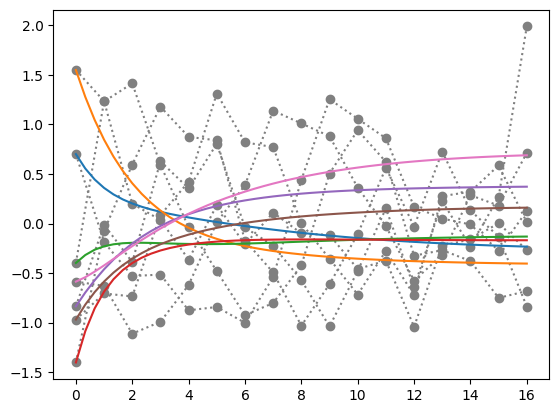

In [28]:
expr = '<Cv> - <Cv> * x + aggr(<Ce> * regular(sour(x/<Cv>), 2))'
prefix_with_coef, single_step, rollout = repeat(expr, N=3, repeat=20)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

11217.157717948774
792725053.1941836
1.8382830268086952
15.392602608131549
0.6385294399029929
212020.25818248495
4482.0449375306835
1093423722051.4769
312.6569627113931
173854116.0859229
517969346.7686569
3.6755571477913778
4392.449815025327
2068.050604892178
12.272027833504367
5063.094632308771
1.464942803556977
691423.8535319271
117.3813922534275
4128.178433827988
Single-step reward: R2=0.3402, RMSE=0.4636, sMAPE=123.28%
Rollout reward: R2=0.0959, RMSE=0.6385, sMAPE=153.26%


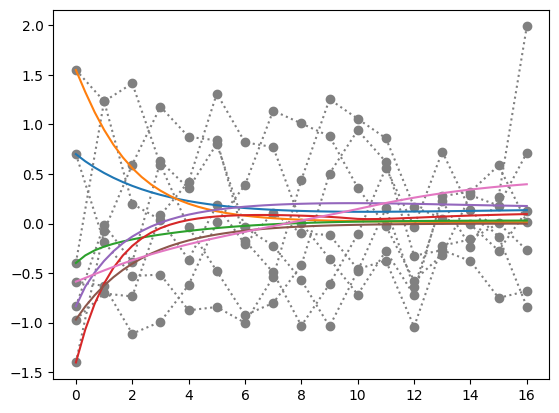

In [30]:
# Michaelis-Menten coupled gene regulatory network (MMC-GRN) model
expr = '- <Cv> * x + exp(<Cv> * aggr(logabs((<Ce>*sour(x)+<Ce>)/sour(x+<Cv>))))'
prefix_with_coef, single_step, rollout = repeat(expr, N=3, repeat=20)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

nan
nan
nan
nan
2.5322343293808096
nan
nan
nan
nan
nan
nan
nan
3.58487266941796
nan
nan
nan
nan
nan
nan
nan
Single-step reward: R2=-2.1279, RMSE=1.0095, sMAPE=144.15%
Rollout reward: R2=nan, RMSE=nan, sMAPE=nan%


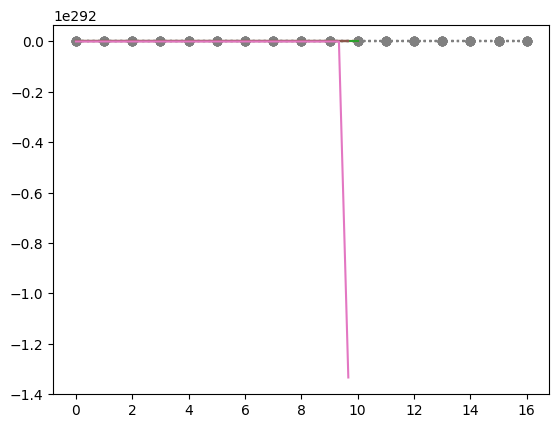

In [3]:
# S-system canonical models
expr = '<Cv> * exp(aggr(<Ce>*logabs(1+sour(x)))) - <Cv> * exp(aggr(1.001*<Ce>*logabs(1+sour(x))))'
prefix_with_coef, single_step, rollout = repeat(expr, N=3, repeat=20)

print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

Rollout reward: R2=0.8549, RMSE=0.2558, sMAPE=67.32%


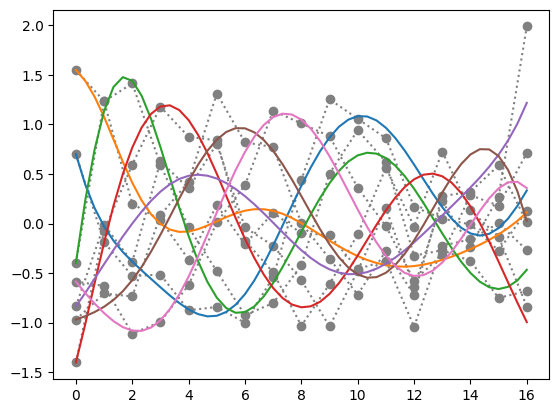

In [10]:
expr = '<C> + <Cv> * x - <C> * regular(2+<C>, aggr(<Ce> * sour(x)))'
prefix_with_coef, single_step, rollout = evaluate(expr, N=3, x0={
    '<C>': np.array([2.225207779612242,4.377678444594488,-0.9066123019642125]),
    '<Cv>': np.array([[-0.4814910172800401,-0.8276040814420217,-0.322373758493994,-0.738755258332401,0.35942851604944487,0.3003187686132258,-0.3902714197671121]]),
    '<Ce>': np.array([[4.081389418438599,-1.1440985200589626,5.207695645289152,-0.7867791146702914,1.9692304334863562,3.3792714301605584,4.001638959423743,-7.165340720527017,3.4825497087628925,2.541458502963009,2.5460853388630755,1.8194908282996363,-3.044334246924369,4.588484162771146,-3.640290750742393,-2.272416679157882,1.6122517995883445,1.8110759511174466,3.3193006588959206,3.6519631754184583,5.762159933684893,7.433226093823112,-1.4689251836343422,0.19862542683017492,-2.718696927737481,-0.3214416079995347,3.1897122315498145,7.935064964450963,7.890356038431611,2.6583317113834277,1.9900867274256435,4.891264171360179,0.9954892847629649,1.4402224697813781,-4.442348001059944,-4.612258369751303,-5.915473225602316,2.4622411288934183,1.0064117078161294,5.803558610057812,8.955902624866692,6.569290337045323]])
}, max_iter=0)
# print(f'Single-step reward: R2={single_step["R2"]:.4f}, RMSE={single_step["RMSE"]:.4f}, sMAPE={single_step["sMAPE"]:.2%}')
print(f'Rollout reward: R2={rollout["R2"]:.4f}, RMSE={rollout["RMSE"]:.4f}, sMAPE={rollout["sMAPE"]:.2%}')

plt.plot(rollout['time'], rollout['true'], 'o:', label='True', color='gray')
for i in range(V):
    plt.plot(rollout['time_all'], rollout['pred_all'][:, i], label='Pred', color=f'C{i}')

In [41]:
import pandas as pd

df = pd.read_json('./result/neural_baseline_gene.csv', lines=True)
df['N'] = df['hidden_dim'].apply(lambda x: len(x))
df['D'] = df['hidden_dim'].apply(lambda x: x[0])
df['hidden_dim'] = df['hidden_dim'].apply(lambda x: str(x))
df

,host,lr,batch_size,dropout,hidden_dim,seed,model,name,time,RMSE,...,ss_sMAPE,sMAPE,epoch,final_loss,final_ssRMSE,final_sssMAPE,final_RMSE,final_sMAPE,N,D
0,rl3,0.0001,2,0.3,"[128, 128]",14546,GNN,NeuralBaseline_20250527_143413,250.035717,0.619751,...,0.603059,0.854137,60,0.208447,0.454270,0.588259,0.621646,0.863152,2,128
1,rl3,0.0001,2,0.3,"[128, 128, 128, 128]",6897,GNN,NeuralBaseline_20250527_143413,317.552296,0.620137,...,0.613337,0.849108,57,0.216909,0.459596,0.585875,0.622536,0.884380,4,128
2,rl3,0.0001,2,0.5,"[32, 32]",6286,GNN,NeuralBaseline_20250527_143413,375.596948,0.618640,...,0.620490,0.875150,17,0.231933,0.464796,0.607033,0.621804,0.857890,2,32
3,rl3,0.0001,2,0.3,"[128, 128, 128]",1327,GNN,NeuralBaseline_20250527_143413,408.485569,0.619035,...,0.602332,0.854022,29,0.207512,0.456132,0.582348,0.622266,0.884577,3,128
4,rl3,0.0001,2,0.3,"[64, 64]",26408,GNN,NeuralBaseline_20250527_143413,408.526196,0.619396,...,0.609960,0.840592,66,0.210983,0.461698,0.594028,0.621198,0.864070,2,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,rl3,0.0100,4,0.0,"[128, 128, 128, 128]",25054,GNN,NeuralBaseline_20250527_184645,596.444536,0.616439,...,0.467128,0.910931,496,0.058426,0.240754,0.320150,0.641465,0.905359,4,128
330,rl3,0.0100,8,0.0,"[64, 64, 64]",3200,GNN,NeuralBaseline_20250527_185057,359.612409,0.619272,...,0.543839,0.850670,146,0.024035,0.152347,0.241602,0.673792,0.815455,3,64
331,rl3,0.0100,8,0.0,"[64, 64, 64, 64]",9689,GNN,NeuralBaseline_20250527_185159,452.058496,0.618578,...,0.195341,0.882406,382,0.000484,0.021844,0.049754,0.654848,0.879423,4,64
332,rl3,0.0100,8,0.0,"[128, 128, 128]",8350,GNN,NeuralBaseline_20250527_185148,500.058093,0.597687,...,0.447720,0.757085,497,0.050867,0.219316,0.274514,0.646512,0.865778,3,128


In [42]:
df.loc[df.groupby('hidden_dim')['RMSE'].idxmin()]

,host,lr,batch_size,dropout,hidden_dim,seed,model,name,time,RMSE,...,ss_sMAPE,sMAPE,epoch,final_loss,final_ssRMSE,final_sssMAPE,final_RMSE,final_sMAPE,N,D
310,rl3,0.001,8,0.0,"[128, 128, 128, 128]",22116,GNN,NeuralBaseline_20250527_183755,394.093218,0.595704,...,0.404747,0.777896,137,0.019932,0.142066,0.234036,0.733193,0.864953,4,128
278,rl3,0.001,2,0.0,"[128, 128, 128]",30866,GNN,NeuralBaseline_20250527_182401,179.940169,0.584675,...,0.309281,0.811252,374,0.057884,0.240575,0.302104,0.585850,0.814599,3,128
312,rl3,0.010,2,0.0,"[128, 128]",27733,GNN,NeuralBaseline_20250527_183845,456.693311,0.574423,...,0.462379,0.711035,203,0.075636,0.274863,0.343059,0.611853,0.850076,2,128
327,rl3,0.010,8,0.0,"[32, 32, 32, 32]",9131,GNN,NeuralBaseline_20250527_185150,145.440972,0.594703,...,0.267689,0.811524,182,0.000061,0.007705,0.011863,0.712481,0.860690,4,32
320,rl3,0.010,8,0.0,"[32, 32, 32]",30464,GNN,NeuralBaseline_20250527_184917,144.078549,0.590085,...,0.274535,0.776720,260,0.000174,0.012865,0.021651,0.719303,0.848250,3,32
192,rl3,0.010,4,0.3,"[32, 32]",8540,GNN,NeuralBaseline_20250527_163620,374.566206,0.600006,...,0.421609,0.785893,93,0.079863,0.260479,0.333199,0.617514,0.855692,2,32
308,rl3,0.010,2,0.0,"[64, 64, 64, 64]",29454,GNN,NeuralBaseline_20250527_184115,165.127816,0.598800,...,0.268795,0.828456,203,0.001298,0.035977,0.073126,0.722493,0.836460,4,64
296,rl3,0.001,4,0.0,"[64, 64, 64]",20522,GNN,NeuralBaseline_20250527_183012,456.502140,0.583356,...,0.377984,0.764196,223,0.043064,0.207095,0.257207,0.662111,0.830437,3,64
303,rl3,0.001,8,0.0,"[64, 64]",2740,GNN,NeuralBaseline_20250527_183313,446.268102,0.600868,...,0.437888,0.750414,225,0.071379,0.265576,0.326677,0.635586,0.874657,2,64
